In [ ]:
!pip -q install yellowbrick

In [1]:
import math
import random
import pickle
import operator
import itertools
import functools
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from yellowbrick.classifier import ConfusionMatrix
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tratamento de Dados
Para poder utilizar alguma das portas, basta descomentar a linha referente a porta e colocar o número de entradas, tenha em mente que o número de entradas é $2^x$, ou seja, pode ser que demore muito para conseguir plotar o gráfico ou treinar os modelos

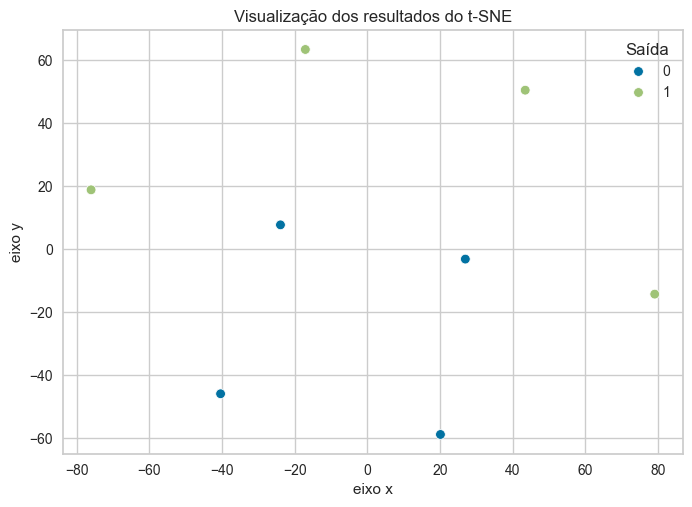

In [28]:
#Número de entradas da tabela verdade
numEntradas = 3

entradas = list(itertools.product([0, 1], repeat=numEntradas))

#porta XOR
saidas = [int(functools.reduce(operator.xor, entrada)) for entrada in entradas]

#porta AND
#saidas = [int(all(entrada)) for entrada in entradas]

#porta OR
#saidas = [int(any(entrada)) for entrada in entradas]

df = pd.DataFrame(entradas, columns=[f'Entrada_{i}' for i in range(0, numEntradas)])
df['Saída'] = saidas
tsne_results = TSNE(n_components=2, perplexity= 3, n_iter=3000).fit_transform(df)
#50 if (2**numEntradas - 2 > 50) else (2**numEntradas - 2)
result = pd.DataFrame(tsne_results, columns=['x', 'y'])


result['Saída'] = saidas
sns.scatterplot(data=result, x="x", y='y', hue='Saída')

plt.xlabel("eixo x")
plt.ylabel("eixo y")
plt.title('Visualização dos resultados do t-SNE')
plt.show()


### Tentativa com  Iris com um único neurônio


In [ ]:
#Caso for usar a Iris, rodar o bloco abaixo
numEntradas = 4
iris_data = pd.read_csv("/content/sample_data/Iris.csv")
features = iris_data[["sepallength","sepalwidth","petallength"]]
#sepallength	sepalwidth	petallength	petalwidth	class

tsne_results = TSNE(n_components=2, perplexity= 5, n_iter=3000).fit_transform(features)
result_iris = pd.DataFrame(tsne_results, columns=['x', 'y'])
result_iris['Saída'] = iris_data["class"]
sns.scatterplot(data=result_iris, x="x", y='y', hue='Saída')

base = iris_data

plt.xlabel("eixo x")
plt.ylabel("eixo y")
plt.title('Visualização dos resultados do t-SNE')
plt.show()


### Separando atributos de entrada e de classe


In [29]:
#ignorar se tiver usando iris como teste
base = df


In [30]:
X_prev = base.iloc[:,0:numEntradas].values


In [31]:
X_prev


array([[0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 1, 0],
       [1, 1, 1]], dtype=int64)

In [32]:
y_classe = base.iloc[:, numEntradas].values

In [33]:
y_classe

array([0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [34]:
#Ignorar se não tiver usando iris
#le = LabelEncoder()
#y_classe = le.fit_transform(y_classe)

Existem dois tipos de definições de treino e testes:


*   Caso for uma porta lógica recomendo não usar a divisão pra treinos, pois o perceptron precisa de todos os casos para funcionar
*   Caso for outro tipo de dataset, talvez dividindo uma parte para treino e teste seja a melhor opção




In [35]:
#portas lógicas
X_treino =  X_teste = X_prev
y_treino = y_teste = y_classe

#divisão para treino e teste
#X_treino, X_teste, y_treino, y_teste = train_test_split(X_prev, y_classe, test_size = 0.40, random_state=0, shuffle=True)


In [36]:
X_treino

array([[0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 1, 0],
       [1, 1, 1]], dtype=int64)

In [37]:
y_treino

array([0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [38]:
X_teste

array([[0, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 1],
       [1, 0, 0],
       [1, 0, 1],
       [1, 1, 0],
       [1, 1, 1]], dtype=int64)

In [39]:
y_teste

array([0, 1, 1, 0, 1, 0, 0, 1], dtype=int64)

In [40]:
with open('port.pkl', mode = 'wb') as f:
  pickle.dump([X_treino, X_teste, y_treino, y_teste], f)

# Perceptron

In [20]:

class Perceptron(BaseEstimator, ClassifierMixin):
  def __init__(self,bias = 1,taxaAprendizagem= 0.3,epocas= 0,tipoAtivacao = "Binary Step",alpha = 1):
    self.bias =bias
    self.taxaAprendizagem = taxaAprendizagem
    self.epocas = epocas
    self.tipoAtivacao = tipoAtivacao
    self.alpha = alpha
    self.w = []


  def getPesos(self):
    return self.w

  def fit(self, X_treino, y_treino):
    self.trainPerceptron(X_treino,y_treino)

  def predict(self,X_teste):
    return self.testPerceptron(X_teste)

  def functionAtivacao(self,x):
    result = 0
    #print(x,self.w)
    for i in range(len(x)):
      result += x[i] * self.w[i]
    match self.tipoAtivacao:
      case "Binary Step":
        result  = 1 if ((result) > 0) else 0
      case "Sigmoidal":
        result = 1/(1+math.e**(-self.alpha*result))
      case _:
        result  = 1 if ((result) > 0) else 0
    return result

  def functionAjusteWeight(self,x,erro):
    for i in range(len(self.w)):
      #print("peso ",(self.w[i] + self.taxaAprendizagem * erro * x[i]), ' = ', self.w[i], ' + ' ,self.taxaAprendizagem, ' * ', erro ,' * ' ,x[i])
      self.w[i] = self.w[i] + self.taxaAprendizagem * erro * x[i]

  def randomWeight(self,tam):
    for i in range(0,tam):
      self.w.append(0.301)

  def trainPerceptron(self,X_treino,y_treino):
    bias_column = np.full((X_treino.shape[0], 1), self.bias)
    X_treino = np.hstack((bias_column, X_treino))
    self.randomWeight(len(X_treino[0]))
    erro_global = 0.001
    numEpocas = 0
    while(numEpocas < self.epocas and erro_global > 0 ):
      erro_global = 0
      for i in range(len(X_treino)):
        #print("funcao ativacao")
        saidaNeuronio = self.functionAtivacao(X_treino[i])
        erro = y_treino[i] - saidaNeuronio
        #print("erro = ",erro, ' = ',self.y_treino[i], ' - ',saidaNeuronio)
        erro_global +=abs(erro)
        if erro != 0:
         # print("ajustando peso:")
          self.functionAjusteWeight(X_treino[i],erro)
      #print("epoca: ",numEpocas)
      #print("erro_global =",erro_global)
      numEpocas+=1

  def testPerceptron(self,X_teste):
    result = []
    bias_column = np.full((X_teste.shape[0], 1), self.bias)
    X_teste =  np.hstack((bias_column, X_teste))
    for i in range(len(X_teste)):
      x = self.functionAtivacao(X_teste[i])
      result.append(x)
    return result



## Uso do Perceptron


In [41]:
with open('port.pkl', 'rb') as f:
  X_treinoP, X_testeP, y_treinoP, y_testeP = pickle.load(f)
#Usar esse bloco se for utilizar baseado nos seus valores

In [42]:
pi = Perceptron(bias = 1, taxaAprendizagem =0.3, epocas = 20)
pi.trainPerceptron(X_treinoP,y_treinoP)
previsao = pi.testPerceptron(X_testeP)
print(previsao)
print(y_testeP)


[0, 0, 1, 1, 1, 1, 1, 1]
[0 1 1 0 1 0 0 1]


In [ ]:
#Usar esse bloco se for utilizar baseado no GridSearchCV
params = {
    'bias': [1, 0],
    'taxaAprendizagem':  np.linspace(0, 1, num=10),
    'epocas': np.linspace(0, 1000, num=100)
}
p = GridSearchCV(estimator = Perceptron(),param_grid=params,cv=2 )
p.fit(X_treinoP,y_treinoP)
melhor_modelo = p.best_estimator_

In [ ]:
melhor_modelo

In [23]:
previsao = p.predict(X_testeP)
print(previsao)
print(y_testeP)

NameError: name 'p' is not defined

0.5

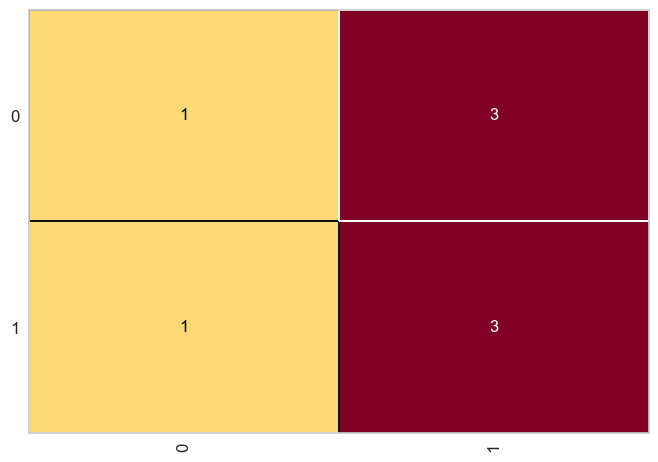

In [43]:
#GridSearchCV
#cm = ConfusionMatrix(p)

#com base em suas escolhas
cm = ConfusionMatrix(pi)
cm.fit(X_treinoP, y_treinoP)
cm.score(X_testeP, y_testeP)

In [44]:
print(classification_report(y_testeP, previsao))

              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.50      0.75      0.60         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.47         8
weighted avg       0.50      0.50      0.47         8

